# Diseño y evaluación de una aplicación móvil con deep learning para la clasificación de frutos de cacao con pudrición negra, daño por pod borer y estado saludable.
## Integrantes
- Adolfo Paucar, Kiltom
- Calderon Matias, Diego Alonso
- La Torre Romero, Jose Luis
- Pardave Jara, Asthri Joanne
- Pumapillo Sarmiento, Bruno


## Importación de librerias

In [ ]:
!pip install split-folders

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import InceptionV3, ResNet50, EfficientNetB0, VGG19
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

import os
import time
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import splitfolders

In [ ]:
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
class_names = ("black_pod_rot", "healthy", "pod_borer")

## Importación del dataset
https://www.kaggle.com/datasets/zaldyjr/cacao-diseases/data
<br>
El conjunto de datos utilizado en este estudio consiste en imágenes de frutos de cacao recolectadas en la ciudad de Davao.
El dataset contiene aproximadamente 4,300 imágenes digitales, todas con una resolución uniforme de 1080 x 1080 píxeles.
<br>
Las imágenes se encuentran organizadas en tres categorías principales, correspondientes al estado fitosanitario del fruto:
- **Black Pod Rot**: incluye imágenes de frutos afectados por la enfermedad de la pudrición negra, una de las patologías más comunes y destructivas del cacao.
- **Healthy**: contiene imágenes de frutos sanos, sin presencia visible de enfermedades o daños.
- **Pod Borer**: agrupa imágenes de frutos afectados por el insecto conocido como barrenador de la mazorca, que causa daños significativos en la producción.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaldyjr/cacao-diseases") + "/cacao_diseases/cacao_photos"

print("Path to dataset files:", path)

100%|██████████| 1.01G/1.01G [00:30<00:00, 35.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zaldyjr/cacao-diseases/versions/1/cacao_diseases/cacao_photos


In [ ]:
splitfolders.ratio(
    path,                    # Carpeta original
    output="dataset_split",  # Carpeta de salida
    seed=42,                 # Para reproducibilidad
    ratio=(0.7, 0.2, 0.1),  # 70% train, 20% val, 10% test
    group_prefix=None
)

Copying files: 4390 files [00:05, 777.06 files/s]


## Preprocessing and data augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalizar
    rotation_range=20,            # Rotar aleatoria ±20°
    width_shift_range=0.2,        # Mover horizontal aleatorio ±20%
    height_shift_range=0.2,       # Mover vertical aleatorio ±20%
    brightness_range=[0.7, 1.3],  # Factor aleatorio de brillo
    zoom_range=0.3,               # Factor aleatorio de zoom
    horizontal_flip=True,         # Efecto espejo
    fill_mode='nearest'
)

## Separacion de dataset en prueba y validación

In [ ]:
# Solo normalización para validación y test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Cargar datasets
train_dataset = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_dataset = val_test_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_dataset = val_test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Training samples: {train_dataset.samples}")
print(f"Validation samples: {validation_dataset.samples}")
print(f"Test samples: {test_dataset.samples}")

Found 3072 images belonging to 3 classes.
Found 876 images belonging to 3 classes.
Found 442 images belonging to 3 classes.
Training samples: 3072
Validation samples: 876
Test samples: 442


## Verificar calidad de imagenes

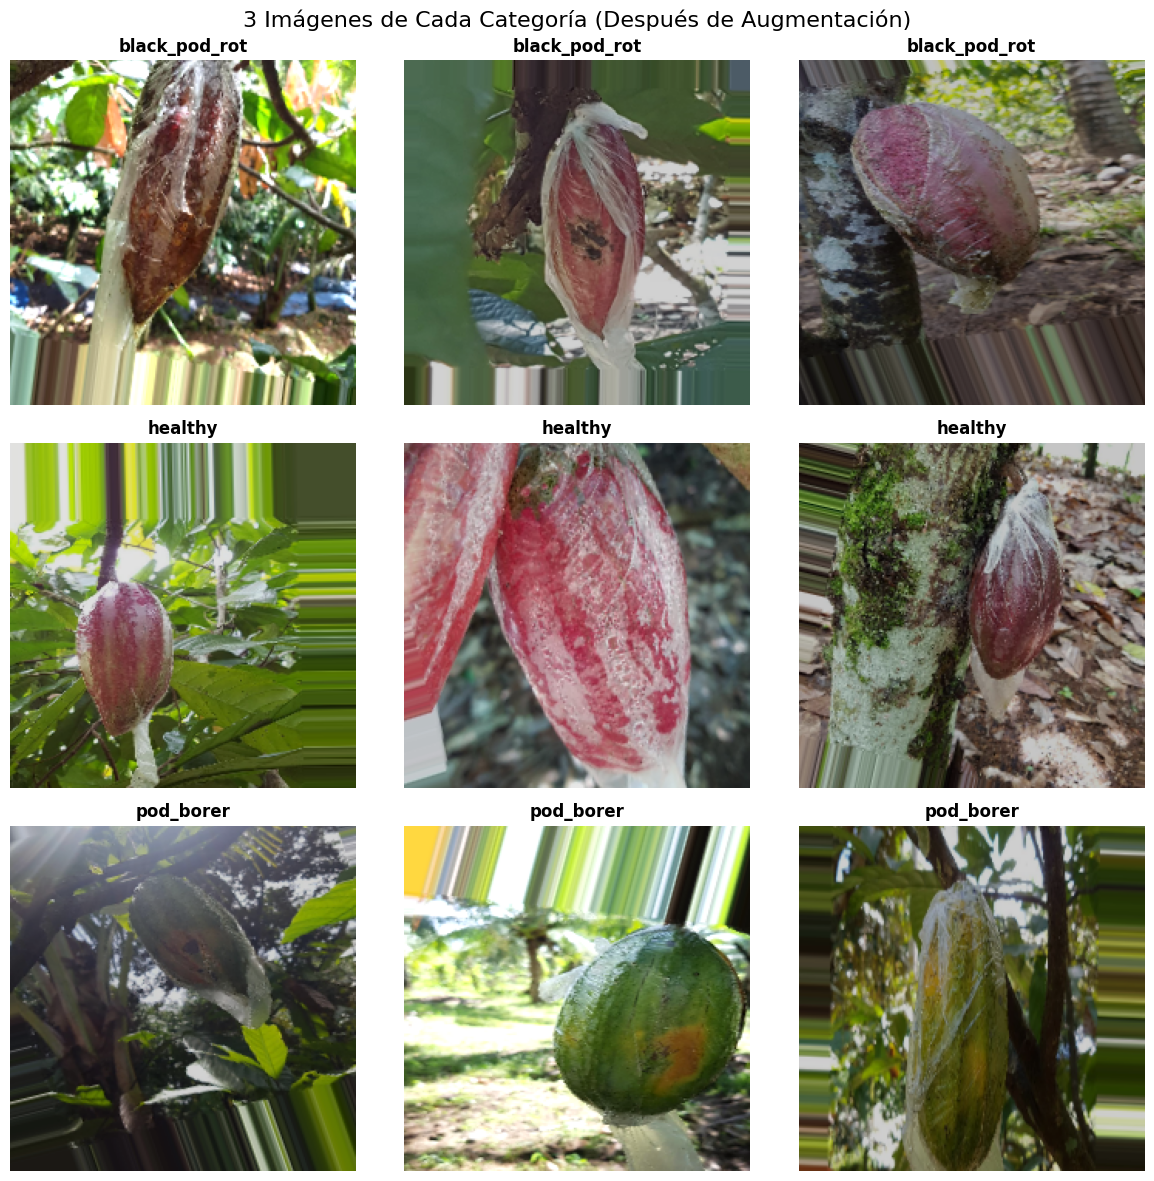

Clases: ['black_pod_rot', 'healthy', 'pod_borer']
Imágenes por categoría: 3
Total imágenes: 9
Shape de las imágenes: (224, 224, 3)


In [ ]:
NUM_POR_CATEGORIA = 3
NUM_IMAGENES_TOTAL = NUM_POR_CATEGORIA * NUM_CLASSES  # 9 imágenes

# Obtener nombres de clases
class_names = list(train_dataset.class_indices.keys())

# Diccionario para almacenar imágenes por categoría
imagenes_por_categoria = {i: [] for i in range(NUM_CLASSES)}

# Recolectar 3 imágenes de cada categoría
while any(len(imgs) < NUM_POR_CATEGORIA for imgs in imagenes_por_categoria.values()):
    batch_images, batch_labels = next(train_dataset)
    labels_indices = np.argmax(batch_labels, axis=1)

    # Agregar imágenes a sus categorías correspondientes
    for img, label_idx in zip(batch_images, labels_indices):
        if len(imagenes_por_categoria[label_idx]) < NUM_POR_CATEGORIA:
            imagenes_por_categoria[label_idx].append(img)

# Crear visualización
plt.figure(figsize=(12, 12))

idx = 1
for categoria_idx in range(NUM_CLASSES):
    for img in imagenes_por_categoria[categoria_idx]:
        plt.subplot(NUM_CLASSES, NUM_POR_CATEGORIA, idx)
        plt.imshow(img)
        plt.title(f'{class_names[categoria_idx]}', fontsize=12, fontweight='bold')
        plt.axis('off')
        idx += 1

plt.suptitle('3 Imágenes de Cada Categoría (Después de Augmentación)', fontsize=16)
plt.tight_layout()
plt.show()

# Información
print(f"Clases: {class_names}")
print(f"Imágenes por categoría: {NUM_POR_CATEGORIA}")
print(f"Total imágenes: {NUM_IMAGENES_TOTAL}")
print(f"Shape de las imágenes: {imagenes_por_categoria[0][0].shape}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2. Crear carpeta para tus modelos
model_dir = '/content/drive/MyDrive/Cacao_Models'
os.makedirs(model_dir, exist_ok=True)

Mounted at /content/drive


In [ ]:
def evaluate_history(history):
  # Extraer métricas
  train_loss = history.history['loss']
  val_loss = history.history['val_loss']
  train_acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  # Visualizar curvas de aprendizaje
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Loss
  axes[0].plot(train_loss, label='Training Loss')
  axes[0].plot(val_loss, label='Validation Loss')
  axes[0].set_title('Model Loss')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid(True)

  # Accuracy
  axes[1].plot(train_acc, label='Training Accuracy')
  axes[1].plot(val_acc, label='Validation Accuracy')
  axes[1].set_title('Model Accuracy')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()


## ENTRENAMIENTO CON INCEPTION V3

In [ ]:
inception_base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar capas del modelo base
for layer in inception_base_model.layers:
  layer.trainable = False

# Construcción del modelo
# x = Flatten()(inception_base_model.output)
# x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
# x = Dropout(0.2)(x)
# predictions = Dense(NUM_CLASSES, activation='softmax')(x)

x = GlobalAveragePooling2D()(inception_base_model.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)  # Normalización adicional
x = Dropout(0.3)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_inceptionV3 = Model(
    inputs=inception_base_model.input,
    outputs=predictions
)
model_inceptionV3.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.7662 - loss: 10.2053
Epoch 1: val_accuracy improved from None to 0.85959, saving model to /content/drive/MyDrive/Cacao_Models/Cacao_InceptionV3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cacao_Models/Cacao_InceptionV3_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7946 - loss: 8.3275 - val_accuracy: 0.8596 - val_loss: 5.2193 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.8190 - loss: 4.4517
Epoch 2: val_accuracy did not improve from 0.85959
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 863ms/step - accuracy: 0.8327 - loss: 3.7519 - val_accuracy: 0.7934 - val_loss: 3.0023 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8438 - loss: 2.2873
Epoch 3: val_accuracy did not improve from 0.85959
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 834ms/step - accuracy: 0.8411 - loss: 2.0228 - val_accuracy: 0.8459 - val_loss: 1.6167 - lea

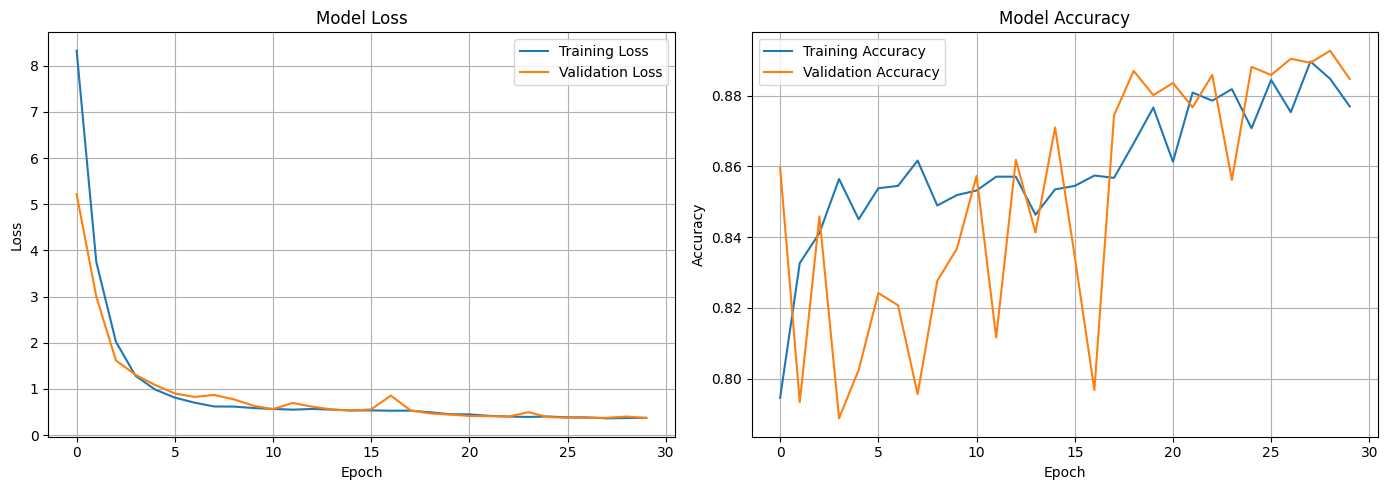

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{model_dir}/Cacao_InceptionV3_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
# Early Stopping: Parar si no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,  # Espera 7 épocas sin mejora
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate: Ajustar LR si se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Nuevo LR = LR actual × 0.2
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_inceptionV3 = model_inceptionV3.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr]
)
evaluate_history(history_inceptionV3)

## ENTRENAMIENTO CON RESNET50

In [ ]:
resnet50_base_model = ResNet50(
    weights='imagenet',        # Pesos pre-entrenados
    include_top=False,         # Sin capa de clasificación
    input_shape=(224, 224, 3)  # Tamaño de entrada
)

# CONGELAR CAPAS DEL MODELO BASE
for layer in resnet50_base_model.layers:
    layer.trainable = False

# ============================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================

# Opción A: Con Flatten
# x = Flatten()(resnet50_base_model.output)
# x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
# x = Dropout(0.2)(x)
# predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Opción B: Con GlobalAveragePooling2D
x = GlobalAveragePooling2D()(resnet50_base_model.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)  # Normalización adicional
x = Dropout(0.3)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)


model_resnet50 = Model(
    inputs=resnet50_base_model.input,
    outputs=predictions
)

# ============================================================
# COMPILAR MODELO
# ============================================================
model_resnet50.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


🚀 Iniciando entrenamiento...

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.6644 - loss: 6.9149
Epoch 1: val_accuracy improved from None to 0.76256, saving model to /content/drive/MyDrive/Cacao_Models/Cacao_ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cacao_Models/Cacao_ResNet50_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7015 - loss: 4.4416 - val_accuracy: 0.7626 - val_loss: 2.4349 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.6900 - loss: 2.1669
Epoch 2: val_accuracy did not improve from 0.76256
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 917ms/step - accuracy: 0.7165 - loss: 1.9525 - val_accuracy: 0.7626 - val_loss: 1.5623 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.7235 - loss: 1.5050
Epoch 3: val_accuracy did not improve from 0.76256
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 915ms/step - accuracy: 0.7334 - loss: 1.4057 - val_accuracy: 0.7626 -

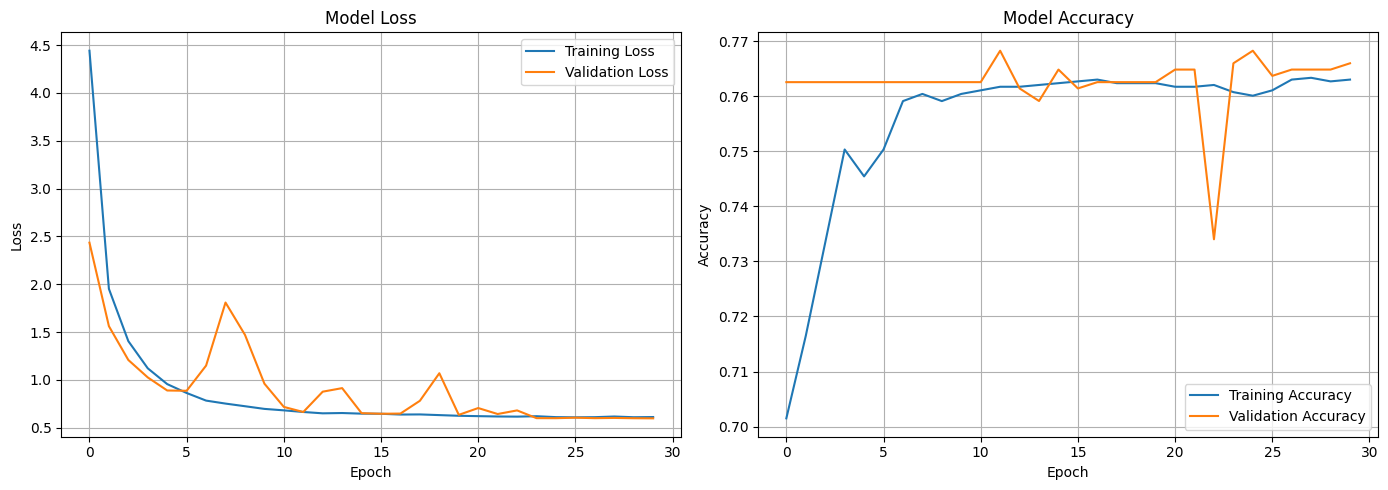

In [ ]:
# Checkpoint: Guardar mejor modelo
checkpoint = ModelCheckpoint(
    filepath=f'{model_dir}/Cacao_ResNet50_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early Stopping: Parar si no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,  # Espera 7 épocas sin mejora
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate: Ajustar LR si se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Nuevo LR = LR actual × 0.2
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ============================================================
# ENTRENAR MODELO
# ============================================================
print("🚀 Iniciando entrenamiento...\n")

history2 = model_resnet50.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr]
)
evaluate_history(history2)

## ENTRENAMIENTO CON EFFICIENTNETB0

In [ ]:
# ============================================================
# MODELO BASE: EfficientNetB0
# ============================================================

efficientnet_base_model = EfficientNetB0(
    weights='imagenet',        # Pesos pre-entrenados
    include_top=False,         # Sin capa de clasificación
    input_shape=(224, 224, 3)  # Tamaño de entrada
)

# CONGELAR CAPAS DEL MODELO BASE
for layer in efficientnet_base_model.layers:
    layer.trainable = False

# ============================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================

# Usar GlobalAveragePooling2D (recomendado para EfficientNet)
x = GlobalAveragePooling2D()(efficientnet_base_model.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_efficientnet = Model(
    inputs=efficientnet_base_model.input,
    outputs=predictions
)

# ============================================================
# COMPILAR MODELO
# ============================================================
model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-3),  # LR inicial ligeramente más alto
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


🚀 Iniciando entrenamiento con EfficientNetB0...

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.6310 - loss: 8.3323
Epoch 1: val_accuracy improved from None to 0.76256, saving model to /content/drive/MyDrive/Cacao_Models/Cacao_EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cacao_Models/Cacao_EfficientNetB0_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6855 - loss: 6.0412 - val_accuracy: 0.7626 - val_loss: 3.0568 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.7225 - loss: 2.6261
Epoch 2: val_accuracy did not improve from 0.76256
96/96 ━━━━━━━━━━━━━━━━━━━━ 87s 901ms/step - accuracy: 0.7373 - loss: 2.2344 - val_accuracy: 0.7626 - val_loss: 1.5661 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.7404 - loss: 1.4941
Epoch 3: val_accuracy did not improve from 0.76256
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 866ms/step - accuracy: 0.7533 - loss: 

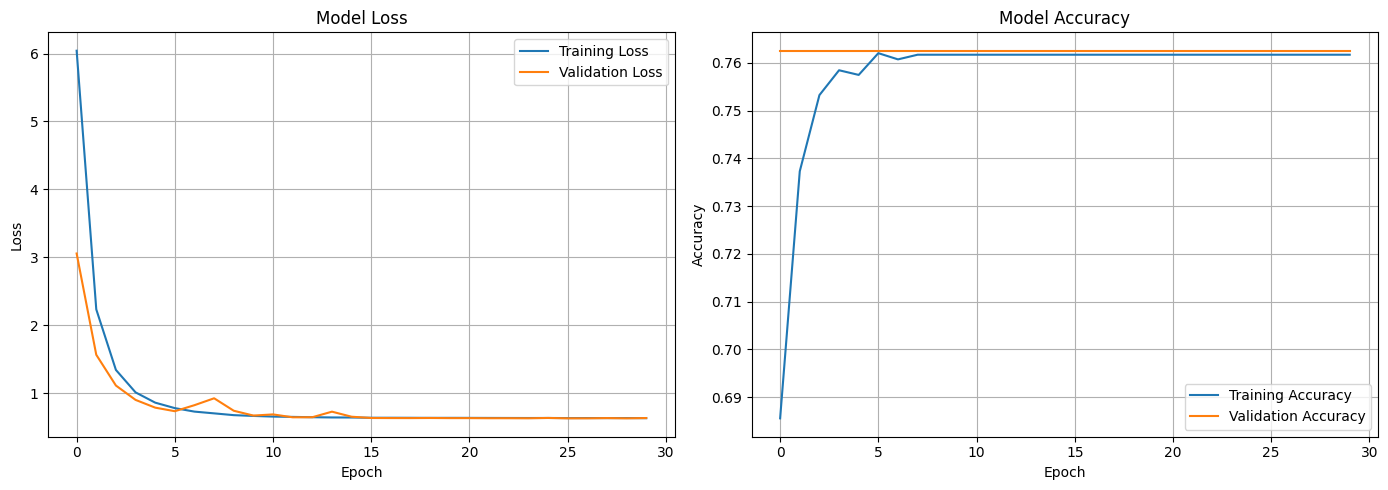

In [ ]:

checkpoint = ModelCheckpoint(
    filepath=f'{model_dir}/Cacao_EfficientNetB0_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early Stopping: Parar si no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate: Ajustar LR si se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ============================================================
# ENTRENAR MODELO
# ============================================================
print("🚀 Iniciando entrenamiento con EfficientNetB0...\n")

history_efficientnet = model_efficientnet.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

evaluate_history(history_efficientnet)

## ENTRENAMIENTO CON VGG19

In [ ]:
# ============================================================
# MODELO BASE: VGG19
# ============================================================

vgg19_base_model = VGG19(
    weights='imagenet',        # Pesos pre-entrenados
    include_top=False,         # Sin capa de clasificación
    input_shape=(224, 224, 3)  # Tamaño de entrada
)

# CONGELAR CAPAS DEL MODELO BASE
for layer in vgg19_base_model.layers:
    layer.trainable = False

# ============================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================

# Usar GlobalAveragePooling2D (más eficiente que Flatten para VGG19)
x = GlobalAveragePooling2D()(vgg19_base_model.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)  # VGG19 se beneficia de más dropout
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_vgg19 = Model(
    inputs=vgg19_base_model.input,
    outputs=predictions
)

# ============================================================
# COMPILAR MODELO
# ============================================================
model_vgg19.compile(
    optimizer=Adam(learning_rate=1e-4),  # LR más bajo (VGG19 es profunda)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


🚀 Iniciando entrenamiento con VGG19...

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.3933 - loss: 9.5767
Epoch 1: val_accuracy improved from None to 0.76256, saving model to /content/drive/MyDrive/Cacao_Models/Cacao_VGG19_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cacao_Models/Cacao_VGG19_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.4909 - loss: 8.9774 - val_accuracy: 0.7626 - val_loss: 7.8602 - learning_rate: 1.0000e-04
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6368 - loss: 7.6717
Epoch 2: val_accuracy improved from 0.76256 to 0.77283, saving model to /content/drive/MyDrive/Cacao_Models/Cacao_VGG19_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cacao_Models/Cacao_VGG19_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 937ms/step - accuracy: 0.6667 - loss: 7.3558 - val_accuracy: 0.7728 - val_loss: 6.7358 - learning_rate: 1.0000e-04
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step

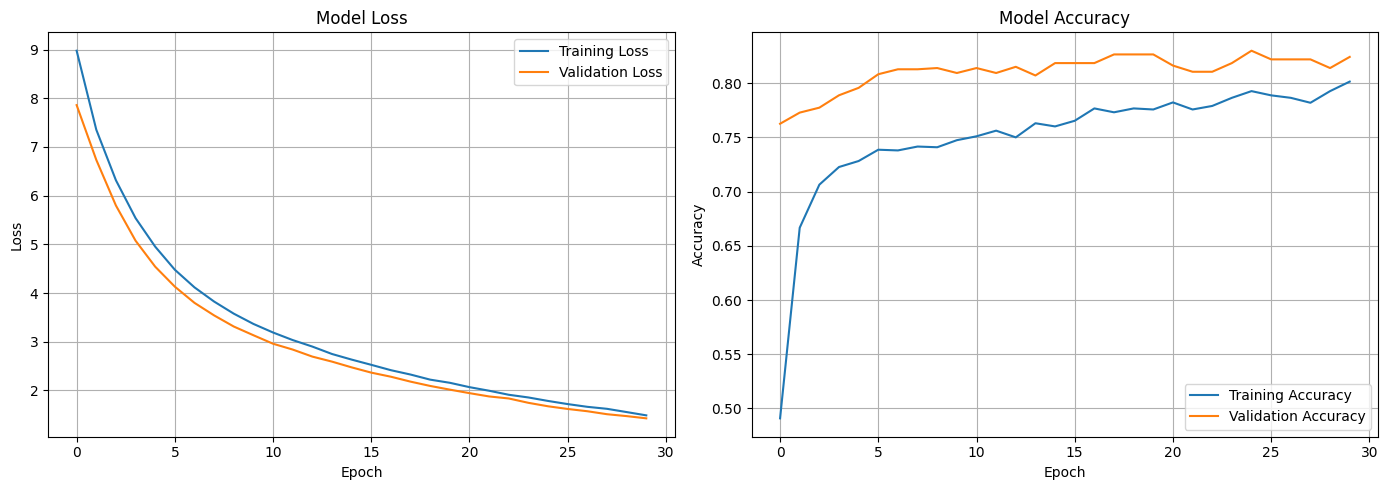

In [ ]:
# Checkpoint: Guardar mejor modelo
checkpoint = ModelCheckpoint(
    filepath=f'{model_dir}/Cacao_VGG19_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early Stopping: Parar si no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate: Ajustar LR si se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ============================================================
# ENTRENAR MODELO
# ============================================================
print("🚀 Iniciando entrenamiento con VGG19...\n")

history_vgg19 = model_vgg19.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

evaluate_history(history_vgg19)

## Evaluar los 4 modelos

In [ ]:
def evaluate_model(model_path, model_name, test_dataset, class_names):
    """
    Función completa para evaluar un modelo
    """
    print(f"\n{'='*50}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*50}\n")

    # Cargar modelo
    model = load_model(f"{model_dir}/{model_path}")

    # Calcular número de steps necesarios para cubrir todo el dataset
    steps = len(test_dataset)  # Número total de batches
    print(f"Total batches to process: {steps}")

    # Predicciones
    print("Predicting...")
    test_dataset.reset()  # Resetear el generador
    y_pred_probs = model.predict(test_dataset, steps=steps, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Etiquetas verdaderas - LIMITAR el número de iteraciones
    print("Extracting true labels...")
    y_true = []
    test_dataset.reset()  # Resetear de nuevo

    for i, (x_batch, y_batch) in enumerate(test_dataset):
        y_true.append(y_batch)
        if i >= steps - 1:  # Parar después de procesar todos los batches
            break

    y_true = np.concatenate(y_true, axis=0)
    y_true = np.argmax(y_true, axis=1)

    # Asegurar que ambos arrays tengan la misma longitud
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    print(f"Samples evaluated: {min_len}")

    # Métricas
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_recall_fscore_support(y_true, y_pred, average='macro')[0],
        'recall': precision_recall_fscore_support(y_true, y_pred, average='macro')[1],
        'f1_score': precision_recall_fscore_support(y_true, y_pred, average='macro')[2],
        'total_params': model.count_params(),
        'model_size_mb': os.path.getsize(model_dir + "/" + model_path) / (1024 * 1024)
    }

    # Tiempo de inferencia
    test_dataset.reset()
    sample_batch = next(iter(test_dataset))
    start = time.time()
    _ = model.predict(sample_batch[0], verbose=0)
    inference_time = (time.time() - start) / sample_batch[0].shape[0] * 1000
    metrics['inference_ms'] = inference_time

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    return metrics, cm, y_pred, y_pred_probs


Evaluating: InceptionV3

Total batches to process: 14
Predicting...
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Extracting true labels...
Samples evaluated: 442

Evaluating: ResNet50

Total batches to process: 14
Predicting...
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 821ms/step
Extracting true labels...
Samples evaluated: 442


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluating: EfficientNet

Total batches to process: 14
Predicting...
14/14 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step
Extracting true labels...
Samples evaluated: 442


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluating: VGG19

Total batches to process: 14
Predicting...
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
Extracting true labels...
Samples evaluated: 442

COMPARISON TABLE
  model_name  accuracy  precision   recall  f1_score  total_params  model_size_mb  inference_ms
 InceptionV3  0.877828   0.772596 0.820745  0.793816      22986019      97.766076    228.477836
    ResNet50  0.769231   0.589041 0.347368  0.316342      24770947     104.155401    144.477792
EfficientNet  0.760181   0.253394 0.333333  0.287918       4839590      25.300422    198.485106
       VGG19  0.837104   0.694819 0.504593  0.540544      20421187      81.031633     30.528471


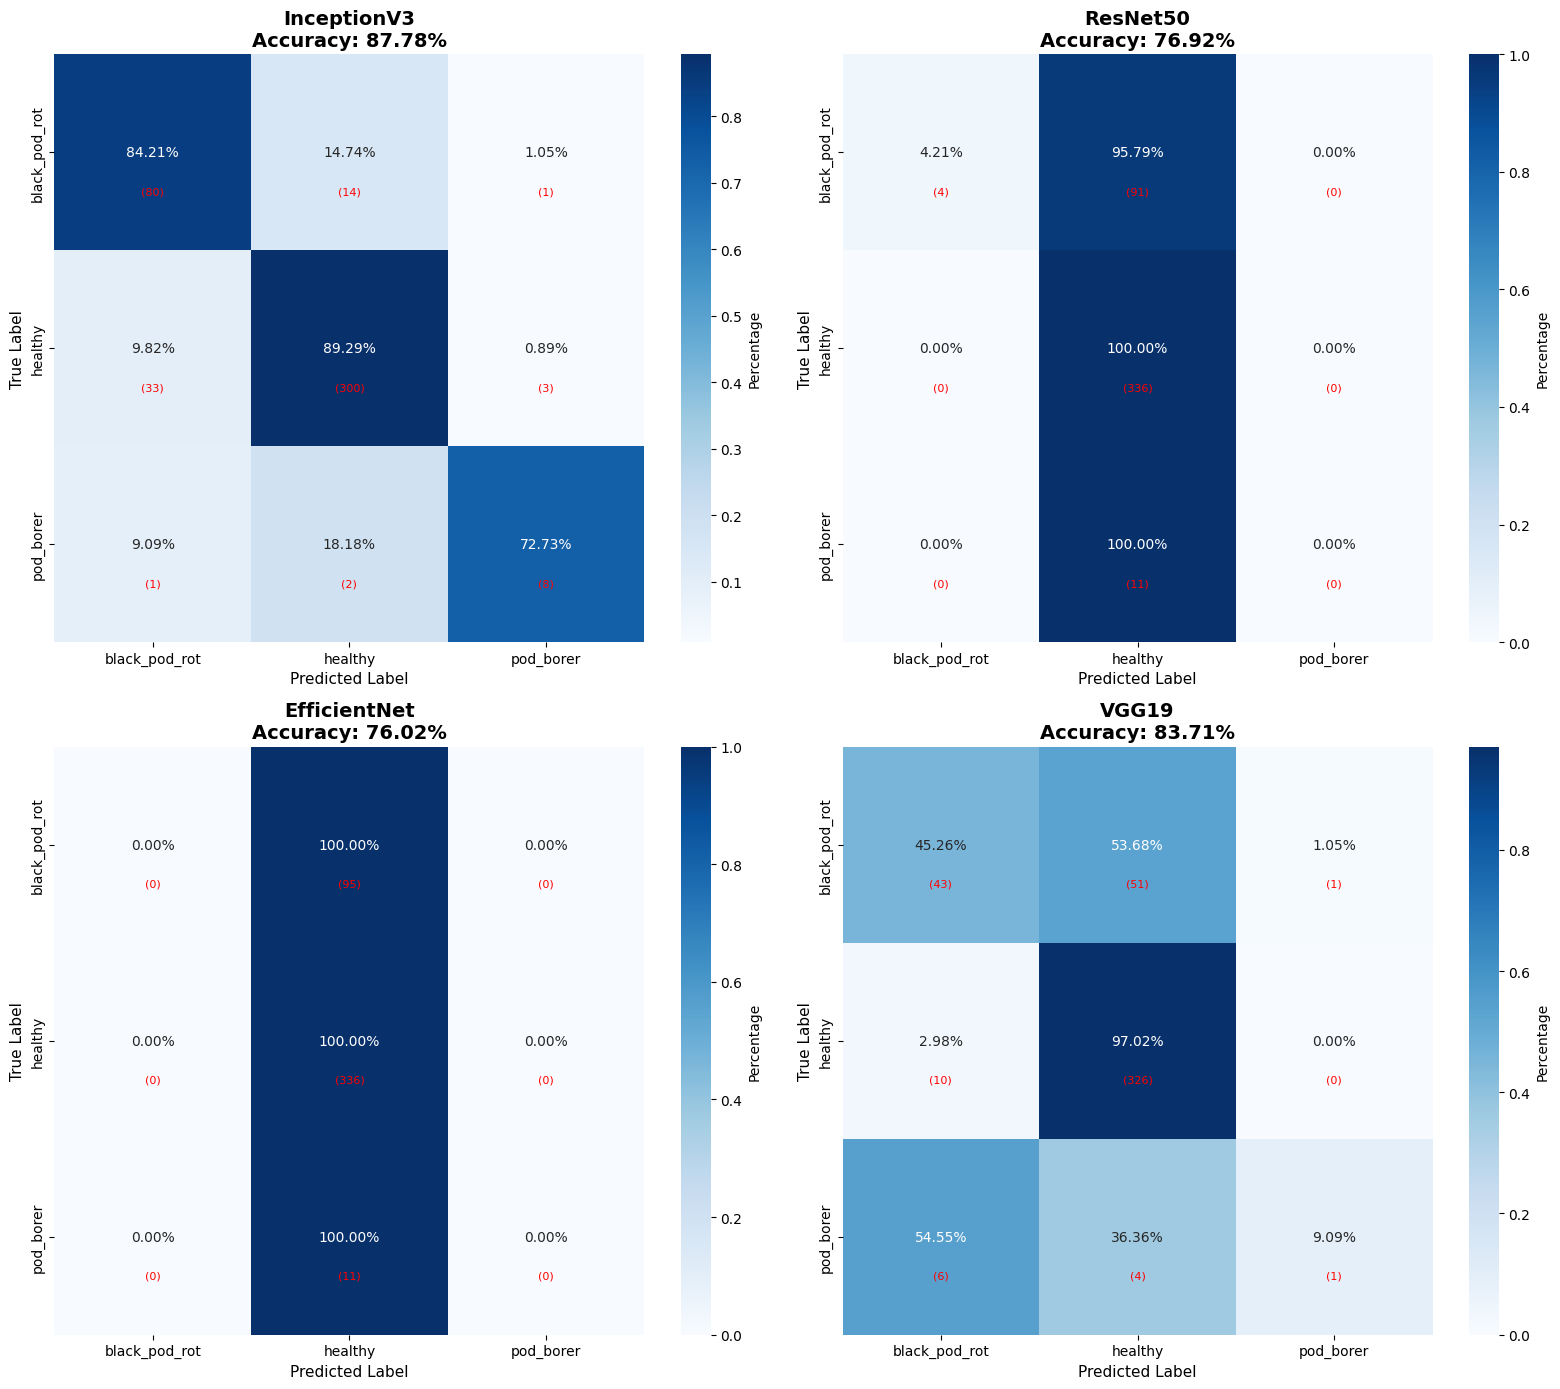


✅ Matrices de confusión guardadas en: /content/drive/MyDrive/Cacao_Models/confusion_matrices_comparison.png


In [ ]:
# Evaluar los 3 modelos
results = []
confusion_matrices = {}
predictions_dict = {}
for model_info in [
    ('Cacao_InceptionV3_best.keras', 'InceptionV3'),
    ('Cacao_ResNet50_best.keras', 'ResNet50'),
    ('Cacao_EfficientNetB0_best.keras', 'EfficientNet'),
    ('Cacao_VGG19_best.keras', 'VGG19')
]:
    metrics, cm, y_pred, y_probs = evaluate_model(
        model_info[0],
        model_info[1],
        test_dataset,
        class_names
    )
    results.append(metrics)
    confusion_matrices[model_info[1]] = cm
    predictions_dict[model_info[1]] = {'y_pred': y_pred, 'y_probs': y_probs}

# Tabla comparativa
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)
print(df_results.to_string(index=False))


# ============================================================
# VISUALIZAR MATRICES DE CONFUSIÓN
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    # Normalizar matriz (mostrar porcentajes)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Crear heatmap
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx],
        cbar_kws={'label': 'Percentage'}
    )

    # Añadir conteos reales en cada celda
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text = axes[idx].text(
                j + 0.5, i + 0.7,
                f'({cm[i, j]})',
                ha="center", va="center",
                color="red", fontsize=8
            )

    axes[idx].set_title(f'{model_name}\nAccuracy: {df_results[df_results["model_name"]==model_name]["accuracy"].values[0]:.2%}',
                        fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(f'{model_dir}/confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Matrices de confusión guardadas en: {model_dir}/confusion_matrices_comparison.png")


In [ ]:
# ============================================================
# Convertir un modelo .keras (Keras v3) a .tflite leyendo/guardando en Google Drive
# ============================================================
# Uso (Colab):
# 1) Cambia MODEL_KERAS_FILENAME por tu archivo .keras
# 2) Cambia DRIVE_MODEL_DIR por la carpeta donde está tu modelo en Drive
# 3) Ejecuta la celda. Genera .tflite en la misma carpeta.

import os
import tensorflow as tf
from google.colab import drive

# ----------------------------
# 1) Montar Drive
# ----------------------------
drive.mount('/content/drive')

# ----------------------------
# 2) Configuración de rutas
# ----------------------------
DRIVE_MODEL_DIR = "/content/drive/MyDrive/Cacao_Models"   # <-- cambia a tu carpeta
MODEL_KERAS_FILENAME = "Cacao_InceptionV3_best.keras"          # <-- cambia a tu modelo .keras

keras_path = os.path.join(DRIVE_MODEL_DIR, MODEL_KERAS_FILENAME)

# Nombre de salida (misma carpeta)
base_name = os.path.splitext(MODEL_KERAS_FILENAME)[0]
tflite_path = os.path.join(DRIVE_MODEL_DIR, f"{base_name}.tflite")

print("Keras model path:", keras_path)
print("TFLite output path:", tflite_path)

if not os.path.exists(keras_path):
    raise FileNotFoundError(f"No se encontró el modelo en: {keras_path}")

# ----------------------------
# 3) Cargar modelo Keras
# ----------------------------
model = tf.keras.models.load_model(keras_path)
model.summary()

# ----------------------------
# 4) Convertir a TFLite (float32 por defecto)
#    (Esta conversión es la más compatible y la primera que recomiendo probar)
# ----------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Opcional) optimización básica (suele reducir un poco y puede mejorar latencia)
# OJO: esto NO cuantiza a int8; solo aplica optimizaciones generales.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# ----------------------------
# 5) Guardar .tflite en Drive
# ----------------------------
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"\n✅ TFLite guardado en: {tflite_path}")
print(f"📦 Tamaño: {size_mb:.2f} MB")

# ----------------------------
# 6) (Opcional) Validación rápida: cargar el TFLite y correr inferencia dummy
# ----------------------------
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nTFLite Input:", input_details)
print("TFLite Output:", output_details)

# Inferencia dummy (ajusta shape si tu input no es 224x224x3)
import numpy as np
input_shape = input_details[0]["shape"]
dummy = np.random.rand(*input_shape).astype(input_details[0]["dtype"])

interpreter.set_tensor(input_details[0]["index"], dummy)
interpreter.invoke()
out = interpreter.get_tensor(output_details[0]["index"])

print("\n✅ Inferencia dummy OK. Output shape:", out.shape)

Mounted at /content/drive
Keras model path: /content/drive/MyDrive/Cacao_Models/Cacao_InceptionV3_best.keras
TFLite output path: /content/drive/MyDrive/Cacao_Models/Cacao_InceptionV3_best.tflite


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 25,350,443 (96.70 MB)

 Trainable params: 1,182,211 (4.51 MB)

 Non-trainable params: 21,803,808 (83.17 MB)

 Optimizer params: 2,364,424 (9.02 MB)

Saved artifact at '/tmp/tmpu30241em'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136634396532688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396535760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396534992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396533264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396534032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396536144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396534608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396534224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396536528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396536720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136634396537680

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
